In [1]:
!pip install numpy matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# Features
# Area (sq ft), Bedrooms
X = np.array([
    [1000, 2],
    [1200, 2],
    [1500, 3],
    [1800, 3],
    [2000, 4],
    [2200, 4],
    [2500, 5],
    [2700, 5]
])

# Target: House Price (in thousands)
y = np.array([200, 220, 300, 340, 360, 400, 450, 480])

In [4]:
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 34.93087557603678
Coefficients: [0.15437788 6.08294931]


In [5]:
# Create grid for Area and Bedrooms
area_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
bedroom_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)

area_grid, bedroom_grid = np.meshgrid(area_range, bedroom_range)

# Flatten and predict
grid_points = np.c_[area_grid.ravel(), bedroom_grid.ravel()]
price_pred = model.predict(grid_points)

price_grid = price_pred.reshape(area_grid.shape)

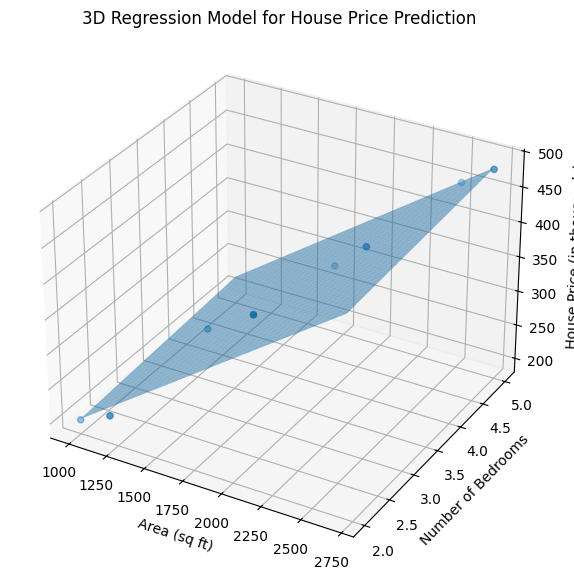

In [6]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot (actual data)
ax.scatter(X[:, 0], X[:, 1], y)

# Surface plot (regression plane)
ax.plot_surface(area_grid, bedroom_grid, price_grid, alpha=0.5)

# Labels
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Number of Bedrooms")
ax.set_zlabel("House Price (in thousands)")

plt.title("3D Regression Model for House Price Prediction")
plt.show()